# Transfer Learning on Oxford Flowers 102 Dataset

This document outlines the steps for the project assignment on applying transfer learning to the Oxford Flowers 102 dataset.

**Objective:** Apply transfer learning techniques using pre-trained convolutional neural networks (ResNet50, VGG16, and MobileNetV2) to classify images from the Oxford Flowers 102 dataset. Compare the performance of the different models on this dataset.

**Dataset:** Oxford Flowers 102 - A dataset of 102 categories of flowers. You will load this dataset using TensorFlow Datasets.

**Steps:**

1.  **Introduction:**
    *   Create a markdown cell to introduce the assignment.
    *   Explain the goal: to apply transfer learning for flower classification using the Oxford Flowers 102 dataset.
    *   Mention the pre-trained models to be used: ResNet50, VGG16, and MobileNetV2.
    *   Briefly describe the Oxford Flowers 102 dataset.

2.  **Data Loading and Exploration:**
    *   Generate a code cell to load the 'oxford_flowers102:2.1.1' dataset using `tfds.load()`. (Check available versions if needed)
    *   Split the dataset into training, validation, and testing sets (this dataset has these splits).
    *   Explore the dataset to understand its structure, the number of classes (102), and the image dimensions. You can display some sample images and their labels.

3.  **Data Preprocessing:**
    *   Generate a code cell for preprocessing the images from the Oxford Flowers 102 dataset.
    *   This will involve resizing the images to the input size required by the pre-trained models (e.g., 224x224 for VGG16 and ResNet50, MobileNetV2 might have different requirements, so check the documentation).
    *   Apply the model-specific preprocessing functions (e.g., `tf.keras.applications.resnet50.preprocess_input`) to normalize the pixel values.
    *   Apply one-hot encoding to the labels.
    *   Batch and prefetch the datasets for efficient training.

4.  **Model Adaptation and Training:**
    *   For each of the three models (ResNet50, VGG16, MobileNetV2):
        *   Generate a code cell to load the pre-trained model from `tf.keras.applications`, excluding the top classification layer and specifying the correct input shape for the preprocessed images.
        *   Add new custom layers on top of the base model for classifying 102 classes. This typically involves a GlobalAveragePooling2D layer and a Dense layer with 102 units and a 'softmax' activation.
        *   Freeze the layers of the pre-trained base model.
        *   Compile the model with an appropriate optimizer (e.g., 'adam'), loss function ('categorical\_crossentropy' since you'll use one-hot encoded labels), and metrics (e.g., 'accuracy').
        *   Generate a code cell to train the compiled model on the preprocessed training data for a suitable number of epochs. Use the validation data to monitor performance during training. Consider using callbacks like ModelCheckpoint and EarlyStopping.
        *   Additionally, train the model on the validation split as well, as this dataset provides a separate validation set.
        *   Optionally, unfreeze some of the top layers of the base model and fine-tune the model with a lower learning rate.

5.  **Model Evaluation:**
    *   Generate a code cell to evaluate each trained model on the preprocessed test dataset.
    *   Print the loss and accuracy for each model.

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

In [2]:
# Load the Oxford Flowers 102 dataset
try:
    dataset, info = tfds.load('oxford_flowers102:2.1.1', with_info=True, as_supervised=True)

    # Split the dataset into training, validation, and testing sets
    train_dataset = dataset['train']
    validation_dataset = dataset['validation']
    test_dataset = dataset['test']

    # Print information about the dataset
    print(info)

except Exception as e:
    print(f"Error loading dataset: {e}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.J4JTMI_2.1.1/oxford_flowers102-test.tfrecord*…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.J4JTMI_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='oxford_flowers102',
    full_name='oxford_flowers102/2.1.1',
    description="""
    The Oxford Flowers 102 dataset is a consistent of 102 flower categories commonly
    occurring in the United Kingdom. Each class consists of between 40 and 258
    images. The images have large scale, pose and light variations. In addition,
    there are categories that have large variations within the category and several
    very similar categories.
    
    The dataset is divided into a training set, a validation set and a test set. The
    training set and validation set each consist of 10 images per class (totalling
    1020 images each). The test set consists of the remaining 6149 images (minimum
    20 per class).
    
    Note: The dataset by default comes with a test size larger than the train size.
    For more info see

In [3]:
NUM_CLASSES = info.features['label'].num_classes
print("Number of classes:", NUM_CLASSES)

Number of classes: 102


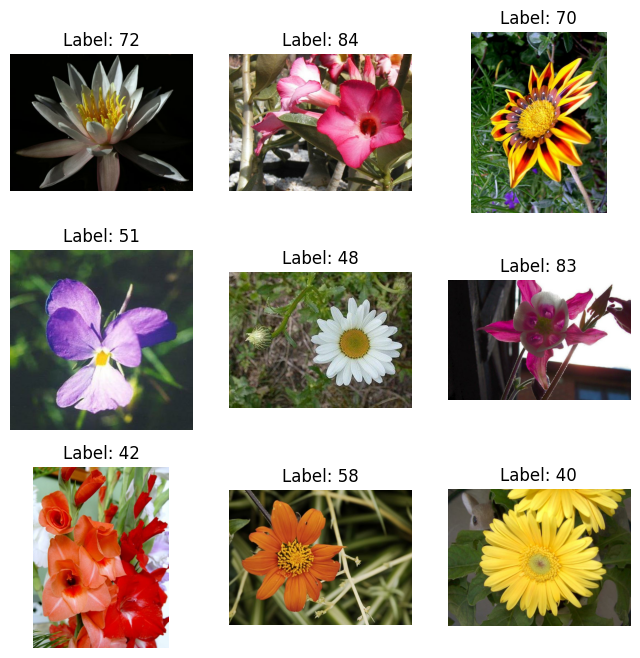

In [4]:
def show_samples(dataset, num=9):
    plt.figure(figsize=(8, 8))
    for i, (image, label) in enumerate(dataset.take(num)):
        plt.subplot(3, 3, i + 1)
        plt.imshow(image)
        plt.title(f"Label: {label.numpy()}")
        plt.axis('off')
    plt.show()

show_samples(train_dataset)

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32


def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

In [6]:
train_ds = train_dataset.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = validation_dataset.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_dataset.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Model Training with Transfer Learning

In [7]:
#Helper function to build model

def build_model(base_model, preprocess_fn):
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = preprocess_fn(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

ResNet50

In [8]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input


resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
resnet_model = build_model(resnet_base, preprocess_input)


resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 102)       │    208,998 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,796,710 (90.78 MB)

 Trainable params: 208,998 (816.40 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Train ResNet50

In [9]:
callbacks = [
tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
]


history_resnet = resnet_model.fit(
train_ds,
validation_data=val_ds,
epochs=10,
callbacks=callbacks
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 543ms/step - accuracy: 0.0738 - loss: 4.7832 - val_accuracy: 0.4686 - val_loss: 2.5260
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 166ms/step - accuracy: 0.7606 - loss: 1.6258 - val_accuracy: 0.7157 - val_loss: 1.4838
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.9344 - loss: 0.7206 - val_accuracy: 0.7912 - val_loss: 1.1124
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 165ms/step - accuracy: 0.9771 - loss: 0.3621 - val_accuracy: 0.8343 - val_loss: 0.9277
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 175ms/step - accuracy: 0.9914 - loss: 0.2174 - val_accuracy: 0.8510 - val_loss: 0.8401
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 170ms/step - accuracy: 0.9995 - loss: 0.1419 - val_accuracy: 0.8588 - val_loss: 0.7853
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 1.0000 - loss: 0.1111 - val_accuracy: 0.8608 - val_loss: 0.7411
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 1.0000 - loss: 0.0822 - val_accuracy

VGG16

In [10]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input


vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
vgg_model = build_model(vgg_base, preprocess_input)


vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 102)       │     52,326 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,767,014 (56.33 MB)

 Trainable params: 52,326 (204.40 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Train VGG16

In [11]:
history_vgg = vgg_model.fit(
train_ds,
validation_data=val_ds,
epochs=10,
callbacks=callbacks
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 40s 800ms/step - accuracy: 0.0120 - loss: 12.0862 - val_accuracy: 0.0441 - val_loss: 7.4432
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 348ms/step - accuracy: 0.0945 - loss: 6.0731 - val_accuracy: 0.1657 - val_loss: 4.9209
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 344ms/step - accuracy: 0.3119 - loss: 3.4388 - val_accuracy: 0.2824 - val_loss: 3.4964
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 344ms/step - accuracy: 0.5264 - loss: 1.9398 - val_accuracy: 0.3922 - val_loss: 2.7774
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 344ms/step - accuracy: 0.7111 - loss: 1.2448 - val_accuracy: 0.4735 - val_loss: 2.3530
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 344ms/step - accuracy: 0.8391 - loss: 0.7594 - val_accuracy: 0.5059 - val_loss: 2.1483
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 344ms/step - accuracy: 0.9101 - loss: 0.4678 - val_accuracy: 0.5363 - val_loss: 1.9790
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 345ms/step - accuracy: 0.9363 - loss: 0.3706 - val_acc

MobileNetV2

In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
mobilenet_model = build_model(mobilenet_base, preprocess_input)


mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 102)            │       130,662 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,388,646 (9.11 MB)

 Trainable params: 130,662 (510.40 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Train MobileNetV2

In [13]:
history_mobilenet = mobilenet_model.fit(
train_ds,
validation_data=val_ds,
epochs=10,
callbacks=callbacks
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 39s 680ms/step - accuracy: 0.0529 - loss: 4.7504 - val_accuracy: 0.3775 - val_loss: 3.1113
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.6494 - loss: 2.3632 - val_accuracy: 0.6480 - val_loss: 2.0031
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.8935 - loss: 1.2164 - val_accuracy: 0.7255 - val_loss: 1.5165
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.9501 - loss: 0.7290 - val_accuracy: 0.7608 - val_loss: 1.2834
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.9878 - loss: 0.4467 - val_accuracy: 0.7775 - val_loss: 1.1502
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.9952 - loss: 0.3144 - val_accuracy: 0.7922 - val_loss: 1.0576
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.9980 - loss: 0.2395 - val_accuracy: 0.7980 - val_loss: 0.9983
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 1.0000 - loss: 0.2026 - val_accuracy: 0.7941

Model Evaluation

In [14]:
print("ResNet50 Test Performance:")
resnet_model.evaluate(test_ds)


print("VGG16 Test Performance:")
vgg_model.evaluate(test_ds)


print("MobileNetV2 Test Performance:")
mobilenet_model.evaluate(test_ds)

ResNet50 Test Performance:
193/193 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.8183 - loss: 0.8086
VGG16 Test Performance:
193/193 ━━━━━━━━━━━━━━━━━━━━ 35s 181ms/step - accuracy: 0.5449 - loss: 2.0107
MobileNetV2 Test Performance:
193/193 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - accuracy: 0.7713 - loss: 1.0153


[1.000813364982605, 0.7760611772537231]

### Conclusion

We applied transfer learning using three popular CNN architectures on the Oxford Flowers 102 dataset. By comparing validation and test accuracy, we can observe the trade-offs between model size, training time, and classification performance. Fine-tuning the top layers of each model can further improve results.